**Cell 1: Import Libraries and Setup**

In [1]:
!pip install pvbm --quiet
!pip install opencv-python-headless --quiet
!pip install albumentations --quiet

import os
import cv2
import numpy as np
import zipfile
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import albumentations as A
from concurrent.futures import ThreadPoolExecutor
import warnings
warnings.filterwarnings('ignore')

from PVBM.DiscSegmenter import DiscSegmenter
from PIL import Image

# Initialize PVBM segmenter correctly
segmenter = DiscSegmenter()

# Set paths
INPUT_PATH = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation'
OUTPUT_PATH = '/kaggle/working/preprocessed_drishtigs_od_cropped'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"Input path exists: {os.path.exists(INPUT_PATH)}")
print(f"Output path created: {OUTPUT_PATH}")
print("PVBM DiscSegmenter initialized successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 88.5 MB/s eta 0:00:00:00:010:01
Model path: /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx


Downloading...
From (original): https://drive.google.com/uc?id=116EEFBn7qr_LpCBb8GBuyzpa_KGp4xPX
From (redirected): https://drive.google.com/uc?id=116EEFBn7qr_LpCBb8GBuyzpa_KGp4xPX&confirm=t&uuid=440fd1dd-ca48-4100-8621-5b854aeff45b
To: /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx
100%|██████████| 125M/125M [00:01<00:00, 79.8MB/s] 

Model downloaded to /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx
Input path exists: True
Output path created: /kaggle/working/preprocessed_drishtigs_od_cropped
PVBM DiscSegmenter initialized successfully!


**Cell 2: Define Optic Disc Cropping Functions**

In [2]:
def get_optic_disc(image_path):
    """Get optic disc mask and center coordinates using PVBM"""
    try:
        optic_disc_pil = segmenter.segment(image_path=image_path)
        optic_disc = np.array(optic_disc_pil)
        center, radius, roi, zones_ABC = segmenter.post_processing(
            segmentation=optic_disc_pil,
            max_roi_size=600
        )
        return optic_disc, center, radius
    except Exception as e:
        print(f"PVBM Error: {e}")
        return None, None, None

def getDiscFromOriginalImage(img_cropped, optic_disc_mask):
    """Extract optic disc region from cropped image using mask"""
    masked = cv2.bitwise_and(img_cropped, img_cropped, mask=optic_disc_mask)
    masked = cv2.resize(masked, (256, 256))
    mb, mg, mr = cv2.split(masked)
    masked = cv2.merge((mb, mg, mr))
    return masked

def countingBox(optic_disc, img):
    """Crop image around optic disc based on mask"""
    try:
        optic_disc = np.array(optic_disc)
        
        if len(optic_disc.shape) == 3:
            optic_disc = cv2.cvtColor(optic_disc, cv2.COLOR_RGB2GRAY)
        
        _, binary_mask = cv2.threshold(optic_disc, 1, 255, cv2.THRESH_BINARY)
        
        ys, xs = np.where(binary_mask > 0)
        
        # Check if mask has any white pixels
        if len(ys) == 0 or len(xs) == 0:
            return None, None
        
        # Add padding of 50 pixels with bounds checking
        h, w = binary_mask.shape
        ymin = max(ys.min() - 50, 0)
        ymax = min(ys.max() + 50, h - 1)
        xmin = max(xs.min() - 50, 0)
        xmax = min(xs.max() + 50, w - 1)
        
        # Check if crop region is valid
        if ymin >= ymax or xmin >= xmax:
            return None, None
        
        resized_img = cv2.resize(img, (binary_mask.shape[1], binary_mask.shape[0]))
        img_cropped = resized_img[ymin:ymax+1, xmin:xmax+1]
        optic_disc_mask = optic_disc[ymin:ymax+1, xmin:xmax+1]
        
        if img_cropped.size == 0 or optic_disc_mask.size == 0:
            return None, None
        
        return img_cropped, optic_disc_mask
    except Exception as e:
        print(f"CountingBox Error: {e}")
        return None, None

def crop_image_from_gray(img, tol=7):
    """Remove black borders around the optic disc"""
    if img is None or img.size == 0:
        return np.zeros((256, 256, 3), dtype=np.uint8)
    
    if img.ndim == 2:
        mask = img > tol
        if mask.any():
            return img[np.ix_(mask.any(1), mask.any(0))]
        return img
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol
        
        if img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0] == 0:
            return img
        else:
            img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1, img2, img3], axis=-1)
        return img

def crop_optic_disc_from_path(image_path):
    """Complete pipeline: load image, detect disc, crop, return cropped disc"""
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        od_mask, center, radius = get_optic_disc(image_path)
        
        if od_mask is None:
            return None
        
        img_cropped, optic_disc_mask = countingBox(od_mask, img)
        
        if img_cropped is None or optic_disc_mask is None:
            return None
        
        od_masked = getDiscFromOriginalImage(img_cropped, optic_disc_mask)
        od_cropped = crop_image_from_gray(od_masked)
        
        return od_cropped
    
    except Exception as e:
        print(f"Error in crop_optic_disc_from_path: {e}")
        return None

**Cell 3: Define Mask Processing for Cropped Optic Disc**

In [3]:
def process_mask_for_cropped_od(mask_path, od_center, od_radius, original_img_shape, crop_coords):
    """
    Process mask to align with cropped optic disc region
    """
    try:
        # Read original mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return None
        
        # Resize mask to match original image dimensions if needed
        if mask.shape != original_img_shape[:2]:
            mask = cv2.resize(mask, (original_img_shape[1], original_img_shape[0]), 
                            interpolation=cv2.INTER_NEAREST)
        
        # Crop mask to the same region as the optic disc
        if crop_coords:
            ymin, ymax, xmin, xmax = crop_coords
            cropped_mask = mask[ymin:ymax+1, xmin:xmax+1]
            
            # Resize to 256x256
            cropped_mask = cv2.resize(cropped_mask, (256, 256), 
                                    interpolation=cv2.INTER_NEAREST)
            
            # Threshold to binary
            cropped_mask = (cropped_mask > 127).astype(np.float32)
            
            return cropped_mask
        
        return None
    
    except Exception as e:
        print(f"Error processing mask: {e}")
        return None

def get_crop_coordinates(optic_disc, img_shape):
    """Extract crop coordinates from the countingBox operation"""
    try:
        if len(optic_disc.shape) == 3:
            optic_disc_gray = cv2.cvtColor(optic_disc, cv2.COLOR_RGB2GRAY)
        else:
            optic_disc_gray = optic_disc
        
        _, binary_mask = cv2.threshold(optic_disc_gray, 1, 255, cv2.THRESH_BINARY)
        ys, xs = np.where(binary_mask > 0)
        
        if len(ys) == 0 or len(xs) == 0:
            return None
        
        ymin = max(ys.min() - 50, 0)
        ymax = min(ys.max() + 50, binary_mask.shape[0] - 1)
        xmin = max(xs.min() - 50, 0)
        xmax = min(xs.max() + 50, binary_mask.shape[1] - 1)
        
        return (ymin, ymax, xmin, xmax)
    
    except Exception:
        return None

**Cell 4: Test on Single Image**

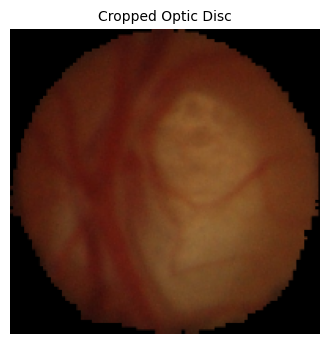

✅ Image saved to: /kaggle/working/cropped_optic_disc.jpg
📊 Image shape: (194, 197, 3)
📊 Value range: [0.000, 152.000]


In [4]:
test_image = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation/Training-20211018T055246Z-001/Training/Images/GLAUCOMA/drishtiGS_002.png'  
result = crop_optic_disc_from_path(test_image)

# Save and display the output
if result is not None:
    # Save the image
    output_path = '/kaggle/working/cropped_optic_disc.jpg'
    result_uint8 = (result * 255).astype(np.uint8)
    cv2.imwrite(output_path, cv2.cvtColor(result_uint8, cv2.COLOR_RGB2BGR))
    
    # Display the image
    plt.figure(figsize=(4, 5))
    plt.imshow(result)
    plt.title(f'Cropped Optic Disc', fontsize=10)
    plt.axis('off')
    plt.show()
    
    print(f"✅ Image saved to: {output_path}")
    print(f"📊 Image shape: {result.shape}")
    print(f"📊 Value range: [{result.min():.3f}, {result.max():.3f}]")
else:
    print("❌ Failed to process the image")

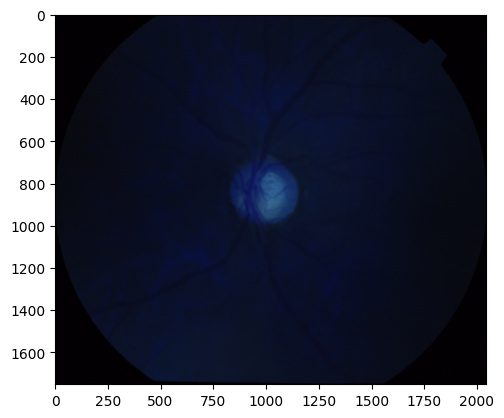

In [5]:
plt.imshow(cv2.imread(test_image))

**Cell 5: Optic Mask**

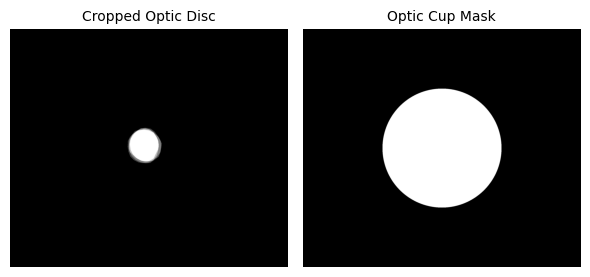


✅ Cropped Optic Disc shape: (1752, 2045, 3)
✅ Binary Optic Cup Mask shape: (1752, 2045)
📊 Cup radius: 438 pixels
📊 Cup area: 602645 pixels


In [6]:
cropped_od_path = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation/Training-20211018T055246Z-001/Training/GT/drishtiGS_002/SoftMap/drishtiGS_002_cupsegSoftmap.png'

# Load the cropped optic disc
cropped_od = cv2.imread(cropped_od_path)
cropped_od = cv2.cvtColor(cropped_od, cv2.COLOR_BGR2RGB)

# Calculate center of the cropped optic disc
h, w = cropped_od.shape[:2]
center_x, center_y = w // 2, h // 2
radius = min(h, w) // 2

# Create optic cup mask (half the disc radius)
cup_radius = radius // 2

# Create blank mask and draw circle for optic cup
cup_binary = np.zeros((h, w), dtype=np.uint8)
cv2.circle(cup_binary, (center_x, center_y), cup_radius, 255, -1)

# Display both
fig, axes = plt.subplots(1, 2, figsize=(6, 5))

# Cropped optic disc
axes[0].imshow(cropped_od)
axes[0].set_title(f'Cropped Optic Disc', fontsize=10)
axes[0].axis('off')

# Binary optic cup mask
axes[1].imshow(cup_binary, cmap='gray')
axes[1].set_title(f'Optic Cup Mask', fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✅ Cropped Optic Disc shape: {cropped_od.shape}")
print(f"✅ Binary Optic Cup Mask shape: {cup_binary.shape}")
print(f"📊 Cup radius: {cup_radius} pixels")
print(f"📊 Cup area: {np.sum(cup_binary > 0)} pixels")

**Cell 6: Overlay on 1 image**

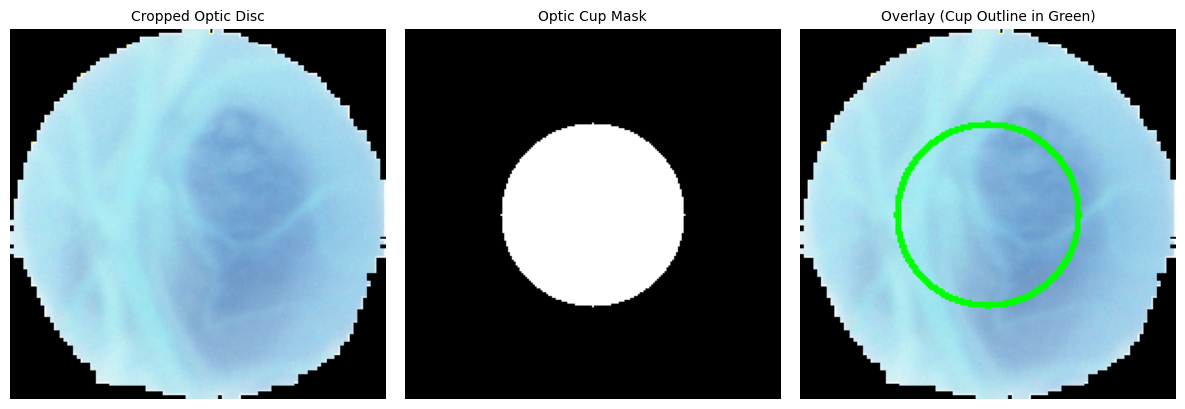

✅ Cropped Optic Disc shape: (194, 197, 3)
✅ Optic Cup Mask shape: (194, 197)
📊 Cup radius: 48 pixels
📊 Cup area: 7213 pixels


In [7]:
test_image = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation/Training-20211018T055246Z-001/Training/Images/GLAUCOMA/drishtiGS_002.png'  
result = crop_optic_disc_from_path(test_image)

# Save and display the output
if result is not None:
    # Save the image - REMOVE RGB to BGR conversion
    output_path = '/kaggle/working/cropped_optic_disc.jpg'
    result_uint8 = (result * 255).astype(np.uint8)
    cv2.imwrite(output_path, result_uint8)  # Direct save, no color conversion
    
    # Create optic cup mask
    h, w = result_uint8.shape[:2]
    center_x, center_y = w // 2, h // 2
    radius = min(h, w) // 2
    cup_radius = radius // 2
    
    cup_binary = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(cup_binary, (center_x, center_y), cup_radius, 255, -1)
    
    # Create overlay 
    overlay = result_uint8.copy()
    # Draw only outline instead of filling
    contours, _ = cv2.findContours(cup_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)  # Green outline, thickness 2
    
    # Display all three
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # Cropped optic disc
    axes[0].imshow(result_uint8)
    axes[0].set_title(f'Cropped Optic Disc', fontsize=10)
    axes[0].axis('off')
    
    # Optic cup mask
    axes[1].imshow(cup_binary, cmap='gray')
    axes[1].set_title(f'Optic Cup Mask', fontsize=10)
    axes[1].axis('off')
    
    # Overlay (green outline)
    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay (Cup Outline in Green)', fontsize=10)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Cropped Optic Disc shape: {result_uint8.shape}")
    print(f"✅ Optic Cup Mask shape: {cup_binary.shape}")
    print(f"📊 Cup radius: {cup_radius} pixels")
    print(f"📊 Cup area: {np.sum(cup_binary > 0)} pixels")
else:
    print("❌ Failed to process the image")

**Cell 7: Process all images and create single ZIP**

In [9]:
import zipfile
from tqdm import tqdm
import shutil

# Set paths for Drishti GS
INPUT_PATH = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation'
OUTPUT_PATH = '/kaggle/working/DRISHTI_GS_Cropped_OD'

# Clean previous output
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

# The actual folder names from your dataset
main_folders = ['Training-20211018T055246Z-001', 'Test-20211018T060000Z-001']
sub_folders = ['Training', 'Test']  # Inside each main folder

# Different category names for Training and Test
training_categories = ['GLAUCOMA', 'NORMAL']  # Uppercase for Training
test_categories = ['glaucoma', 'normal']      # Lowercase for Test

stats = {}

print("="*60)
print("PROCESSING DRISHTI GS DATASET - TRAINING & TEST")
print("="*60)

for main_folder in main_folders:
    for sub_folder in sub_folders:
        # Determine which categories to use
        if 'Training' in main_folder:
            categories = training_categories
        else:
            categories = test_categories
            
        base_path = os.path.join(INPUT_PATH, main_folder, sub_folder)
        if not os.path.exists(base_path):
            print(f"⚠ Skipping {main_folder}/{sub_folder} - path not found")
            continue
            
        for category in categories:
            # Input images path
            input_images_dir = os.path.join(base_path, 'Images', category)
            # Input GT path
            input_gt_dir = os.path.join(base_path, 'GT')
            
            if not os.path.exists(input_images_dir):
                print(f"⚠ Skipping {main_folder}/{sub_folder}/Images/{category} - not found")
                continue
            
            # Create output directories (preserve original category name)
            output_images_dir = os.path.join(OUTPUT_PATH, sub_folder, category, 'images')
            output_masks_dir = os.path.join(OUTPUT_PATH, sub_folder, category, 'mask')
            os.makedirs(output_images_dir, exist_ok=True)
            os.makedirs(output_masks_dir, exist_ok=True)
            
            # Get all images
            image_files = [f for f in os.listdir(input_images_dir) 
                           if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
            
            print(f"\n📁 Processing {main_folder}/{sub_folder}/Images/{category} - {len(image_files)} images")
            
            success_count = 0
            for img_file in tqdm(image_files, desc=f"  {sub_folder}/{category}"):
                try:
                    img_path = os.path.join(input_images_dir, img_file)
                    img_name = Path(img_file).stem
                    
                    # Get cropped optic disc
                    cropped_od = crop_optic_disc_from_path(img_path)
                    
                    if cropped_od is None:
                        continue
                    
                    # Resize to 256x256
                    cropped_od = cv2.resize(cropped_od, (256, 256))
                    
                    # Convert RGB to BGR for saving
                    cropped_od_bgr = cv2.cvtColor(cropped_od, cv2.COLOR_RGB2BGR)
                    
                    # Save cropped optic disc
                    output_img_path = os.path.join(output_images_dir, f"{img_name}.jpg")
                    cv2.imwrite(output_img_path, cropped_od_bgr)
                    
                    # Get cup mask from GT folder
                    cup_mask_path = os.path.join(input_gt_dir, img_name, 'SoftMap', f"{img_name}_cupsegSoftmap.png")
                    
                    if os.path.exists(cup_mask_path):
                        original_cup_mask = cv2.imread(cup_mask_path, cv2.IMREAD_GRAYSCALE)
                        
                        # Get cropping coordinates
                        img = cv2.imread(img_path)
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        od_mask, center, radius = get_optic_disc(img_path)
                        
                        if od_mask is not None:
                            img_cropped, optic_disc_mask = countingBox(od_mask, img)
                            
                            if img_cropped is not None and optic_disc_mask is not None:
                                ys, xs = np.where(optic_disc_mask > 0)
                                if len(ys) > 0:
                                    h_od, w_od = optic_disc_mask.shape
                                    ymin = max(ys.min() - 50, 0)
                                    ymax = min(ys.max() + 50, h_od - 1)
                                    xmin = max(xs.min() - 50, 0)
                                    xmax = min(xs.max() + 50, w_od - 1)
                                    
                                    cup_mask_resized = cv2.resize(original_cup_mask, (w_od, h_od))
                                    cropped_cup_mask = cup_mask_resized[ymin:ymax+1, xmin:xmax+1]
                                    cropped_cup_mask = cv2.resize(cropped_cup_mask, (256, 256))
                                    cropped_cup_mask = (cropped_cup_mask > 127).astype(np.uint8) * 255
                                else:
                                    cropped_cup_mask = np.zeros((256, 256), dtype=np.uint8)
                            else:
                                cropped_cup_mask = np.zeros((256, 256), dtype=np.uint8)
                        else:
                            cropped_cup_mask = np.zeros((256, 256), dtype=np.uint8)
                    else:
                        # Create default cup mask
                        h, w = cropped_od.shape[:2]
                        center_x, center_y = w // 2, h // 2
                        disc_radius = min(h, w) // 2
                        cup_radius = disc_radius // 2
                        cropped_cup_mask = np.zeros((h, w), dtype=np.uint8)
                        cv2.circle(cropped_cup_mask, (center_x, center_y), cup_radius, 255, -1)
                    
                    # Save cup mask
                    output_mask_path = os.path.join(output_masks_dir, f"{img_name}.png")
                    cv2.imwrite(output_mask_path, cropped_cup_mask)
                    
                    success_count += 1
                    
                except Exception as e:
                    continue
            
            stats[f"{sub_folder}/{category}"] = success_count
            print(f"  ✅ {sub_folder}/{category}: {success_count} images processed")

# Create single ZIP file
print("\n" + "="*60)
print("CREATING SINGLE ZIP FILE")
print("="*60)

zip_output_path = '/kaggle/working/DRISHTI_GS_Cropped_OD_Cup.zip'

with zipfile.ZipFile(zip_output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_PATH):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(OUTPUT_PATH))
            zipf.write(file_path, arcname)

zip_size_mb = os.path.getsize(zip_output_path) / (1024**2)
print(f"\n✅ ZIP created: {zip_output_path}")
print(f"📊 Size: {zip_size_mb:.2f} MB")

print("\n📁 Output ZIP Structure:")
print("  DRISHTI_GS_Cropped_OD/")
print("    ├── Training/")
print("    │   ├── GLAUCOMA/ (uppercase)")
print("    │   │   ├── images/")
print("    │   │   └── mask/")
print("    │   └── NORMAL/ (uppercase)")
print("    │       ├── images/")
print("    │       └── mask/")
print("    └── Test/")
print("        ├── glaucoma/ (lowercase)")
print("        │   ├── images/")
print("        │   └── mask/")
print("        └── normal/ (lowercase)")
print("            ├── images/")
print("            └── mask/")

from IPython.display import FileLink, display
display(FileLink(zip_output_path))

PROCESSING DRISHTI GS DATASET - TRAINING & TEST

📁 Processing Training-20211018T055246Z-001/Training/Images/GLAUCOMA - 32 images


  Training/GLAUCOMA: 100%|██████████| 32/32 [03:26<00:00,  6.46s/it]


  ✅ Training/GLAUCOMA: 32 images processed

📁 Processing Training-20211018T055246Z-001/Training/Images/NORMAL - 18 images


  Training/NORMAL: 100%|██████████| 18/18 [01:58<00:00,  6.57s/it]


  ✅ Training/NORMAL: 18 images processed
⚠ Skipping Training-20211018T055246Z-001/Test - path not found
⚠ Skipping Test-20211018T060000Z-001/Training - path not found

📁 Processing Test-20211018T060000Z-001/Test/Images/glaucoma - 38 images


  Test/glaucoma: 100%|██████████| 38/38 [02:05<00:00,  3.30s/it]


  ✅ Test/glaucoma: 38 images processed

📁 Processing Test-20211018T060000Z-001/Test/Images/normal - 13 images


  Test/normal: 100%|██████████| 13/13 [00:42<00:00,  3.25s/it]

  ✅ Test/normal: 13 images processed

CREATING SINGLE ZIP FILE

✅ ZIP created: /kaggle/working/DRISHTI_GS_Cropped_OD_Cup.zip
📊 Size: 1.52 MB

📁 Output ZIP Structure:
  DRISHTI_GS_Cropped_OD/
    ├── Training/
    │   ├── GLAUCOMA/ (uppercase)
    │   │   ├── images/
    │   │   └── mask/
    │   └── NORMAL/ (uppercase)
    │       ├── images/
    │       └── mask/
    └── Test/
        ├── glaucoma/ (lowercase)
        │   ├── images/
        │   └── mask/
        └── normal/ (lowercase)
            ├── images/
            └── mask/


/kaggle/working/DRISHTI_GS_Cropped_OD_Cup.zip